In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
path_to_parameter_files = "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/saturation_effects/"
os.makedirs(path_to_parameter_files, exist_ok = True)

## Creating parameters to sample ranges for testing the impact of $k_{on}$ and $k_{add}$


In [ ]:
import pandas as pd
import numpy as np

# Fixed burst probability

# Column headers
columns = [
    "k_on", "k_off", "mrna_half_life", "protein_half_life",
    "k_prod_mRNA", "k_prod_protein", "n_gene_1_to_gene_2",
    "k_add_gene_1","k_add_gene_2", "k_add_gene_2", "pair_id", "gene_id", "burst_frac"
]

# Fixed values for gene_1
base_gene_1 = [
    0.66, 8.6,
    4, 45, 2, 560, 2,
    6, 6, 6, 6, 6, # k_add placeholder
    0, 1, 0.07
]

# Base template for gene_2 (will be overwritten)
base_gene_2 = [
    0.66, 0.0, 5, 45, 2, 560, 2, 
    6, 6, 6, 6, 6,  # k_add will be updated
    0, 2, 0
]

base_gene_3 = [
    0.66, 0.0, 5, 45, 2, 560, 2, 
    6, 6, 6, 6, 6,  # k_add will be updated
    0, 3, 0
]


# Grid sampling
burst_prob_values = [0.07]
k_add_k_on_ratio =  np.logspace(np.log10(0.5), np.log10(20), 10)
# k_add_k_on_ratio =  np.linspace(0.5, 50)

rows = []
pair_id = 0

for burst_prob in burst_prob_values:
    k_on = 0.66
    k_off =((1 /burst_prob) - 1)*k_on
    if k_off > 55 or k_off < 0.06:
        continue
    k = 10
    for i in range(k):
        for k_add_ratio in k_add_k_on_ratio:
            # Gene 1 (fixed, except pair_id)
            gene_1 = base_gene_1.copy()
            k_on = gene_1[0]
            k_add = k_add_ratio*k_on
            gene_1[7] = k_add
            gene_1[8] = k_add
            gene_1[9] = k_add
            gene_1[10] = k_add
            gene_1[11] = k_add
            gene_1[12] = pair_id  # pair_id
            gene_1[-1] = burst_prob
            # Gene 2 (grid-sampled)
            gene_2 = base_gene_2.copy()
            gene_2[1] = k_off
            gene_2[7] = k_add
            gene_2[8] = k_add
            gene_2[9] = k_add
            gene_2[10] = k_add
            gene_2[11] = k_add
            gene_2[12] = pair_id  # pair_id
            gene_2[-1] = burst_prob
            gene_3 = base_gene_3.copy()
            gene_3[1] = k_off
            gene_3[7] = k_add
            gene_3[8] = k_add
            gene_3[9] = k_add
            gene_3[10] = k_add
            gene_3[11] = k_add
            gene_3[12] = pair_id  # pair_id
            gene_3[-1] = burst_prob
            rows.append(gene_1)
            rows.append(gene_2)
            rows.append(gene_3)
            pair_id += 1

# Convert and save
df = pd.DataFrame(rows, columns=columns)
df.to_csv(f"{path_to_parameter_files}/effect_of_k_add_sampling_positive_with_reps.csv")


In [9]:
df

,k_on,k_off,mrna_half_life,protein_half_life,k_prod_mRNA,k_prod_protein,n_gene_1_to_gene_2,k_add_gene_1_to_gene_2,k_add_gene_2_to_gene_1,k_add_gene_2_to_gene_3,k_add_gene_1_to_gene_3,k_add_gene_3_to_gene_2,pair_id,gene_id,burst_frac
0,0.66,8.600000,4,45,2,560,2,0.330000,0.330000,0.330000,0.330000,0.330000,0,1,0.07
1,0.66,8.768571,5,45,2,560,2,0.330000,0.330000,0.330000,0.330000,0.330000,0,2,0.07
2,0.66,8.768571,5,45,2,560,2,0.330000,0.330000,0.330000,0.330000,0.330000,0,3,0.07
3,0.66,8.600000,4,45,2,560,2,0.497188,0.497188,0.497188,0.497188,0.497188,1,1,0.07
4,0.66,8.768571,5,45,2,560,2,0.497188,0.497188,0.497188,0.497188,0.497188,1,2,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.66,8.768571,5,45,2,560,2,8.761274,8.761274,8.761274,8.761274,8.761274,98,2,0.07
296,0.66,8.768571,5,45,2,560,2,8.761274,8.761274,8.761274,8.761274,8.761274,98,3,0.07
297,0.66,8.600000,4,45,2,560,2,13.200000,13.200000,13.200000,13.200000,13.200000,99,1,0.07
298,0.66,8.768571,5,45,2,560,2,13.200000,13.200000,13.200000,13.200000,13.200000,99,2,0.07


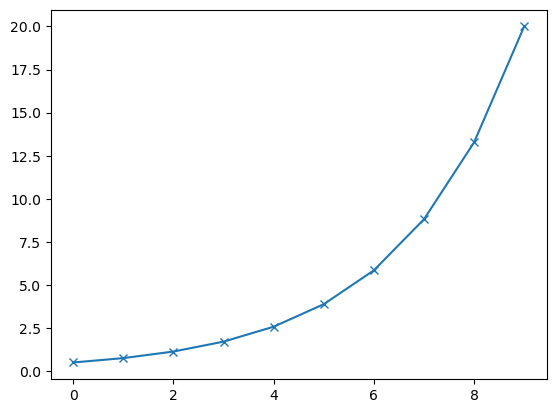

In [14]:
plt.plot(range(len(k_add_k_on_ratio*0.66)), k_add_k_on_ratio, marker = "x")
# plt.axhline(10)
plt.show()

In [36]:
import pandas as pd
import numpy as np

# Fixed burst probability

# Column headers
columns = [
    "k_on", "k_off", "mrna_half_life", "protein_half_life",
    "k_prod_mRNA", "k_prod_protein", "n_gene_1_to_gene_2",
    "k_add_gene_1_to_gene_2", "pair_id", "gene_id", "burst_frac"
]

# Fixed values for gene_1
base_gene_1 = [
    0.66,
    8.6,
    4, 45, 2, 560, 2, 6,  # k_add placeholder
    0, 1, 0.07
]

# Base template for gene_2 (will be overwritten)
base_gene_2 = [
    0.66, 0.0, 5, 45, 2, 560, 2, 0.0,  # k_add will be updated
    0, 2, 0
]

# Grid sampling
burst_prob_values = np.logspace(np.log10(0.002), np.log10(0.4), 10)
k_add_k_on_ratio = np.logspace(np.log10(0.5), np.log10(5), 10)
burst_prob_values = np.append(burst_prob_values, 0.07)

rows = []
pair_id = 0

for burst_prob in burst_prob_values:
     
    k_off =((1 /burst_prob) - 1)*k_on
    if k_off > 55 or k_off < 0.06:
        continue
    for k_add_ratio in k_add_k_on_ratio:
        for i in range(20):
            # Gene 1 (fixed, except pair_id)
            gene_1 = base_gene_1.copy()
            k_on = gene_1[0]
            k_add = k_add_ratio*k_on
            gene_1[7] = k_add
            gene_1[8] = pair_id  # pair_id
            gene_1[-1] = burst_prob
            # Gene 2 (grid-sampled)
            gene_2 = base_gene_2.copy()
            gene_2[1] = k_off
            gene_2[7] = k_add
            gene_2[8] = pair_id  # pair_id
            gene_2[-1] = burst_prob
            rows.append(gene_1)
            rows.append(gene_2)

            pair_id += 1

# Convert and save
df = pd.DataFrame(rows, columns=columns)

df.to_csv(f"{path_to_parameter_files}effect_of_k_add_sampling_repression_with_reps.csv")
